<a href="https://colab.research.google.com/github/NoaTal1996/Backbone-Graph/blob/main/src/key_authors_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

Note: google drive is no longer suppurted. Adjust the input and output path if nedded.

In [1]:
# File System
from pathlib import Path

# ML
import pandas as pd
import numpy as np

# Plot
import matplotlib.pyplot as plt

# TF-IDf
from sklearn.feature_extraction.text import TfidfVectorizer

# Graphs
import networkx as nx
import matplotlib.patches as mpatches

# sklearn
from sklearn.feature_selection import mutual_info_classif

# General
import math
from collections.abc import Iterable

# Loading and Exporting

## Parameters

In [ ]:
dataset_folder = "Labeled_Datasets/Ecuador"   # folder path
file_name = "Ecuador_part_3.gzip.parquet"  # file name
dataset_procced_date = "2025_12_25"        # ("%Y_%m_%d")

# Recommended: working directory is: "Backbone-Graph/src"

## Load Data

In [ ]:
# Note: Google Colab not supported anymore.

# Cluster\Local
# Recommended: working directory is: "Backbone-Graph/src"
file_name_no_suffixes = file_name.split(".")[0]
processed_dataset_path = Path("../results") / dataset_folder / file_name_no_suffixes / dataset_procced_date
# Example: ""../results/Labeled_Datasets/Ecuador/Ecuador_part_4/2025_11_27"
print(f"Running on local/cluster.\nLoading data from: {processed_dataset_path}")

# Load the parquet file
df = pd.read_parquet(processed_dataset_path / f"Topic_Ner_{file_name}")

# for testing
# df = df.sample(n = 50).reset_index(drop=True)

Running on local/cluster.
Loading data from: ../results/Labeled_Datasets/Ecuador/Ecuador_part_1/2025_12_16


## Output

In [ ]:
folder_output_path = processed_dataset_path # save in the save folder as the processed dataset

# Dataset collums

In [5]:
print(f"df shpe: {df.shape}")
print("")
print(f"{'**collum name**':<30} **value type**")
for col in df.columns:
    # dtype_str = str(df[col].dtype)  # Convert dtype to string
    # get a sample non-null value if exists
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")

df shpe: (50, 26)

**collum name**                **value type**
postid                         | str
post_text                      | str
application_name               | str
post_language                  | str
in_reply_to_postid             | str
in_reply_to_accountid          | str
post_time                      | Timestamp
accountid                      | str
account_profile_description    | str
follower_count                 | int64
following_count                | int64
account_creation_date          | date
is_repost                      | bool
reposted_accountid             | str
reposted_postid                | str
hashtags                       | ndarray
urls                           | ndarray
account_mentions               | ndarray
is_control                     | bool
clean_post_text                | str
clean_text_no_enteties         | str
translated_post                | str
BERTopic_topic                 | int64
BERTopic_prob                  | float64
K_Means_topic   

# TF-IDF Score

## Entities

TF-IDF Using *sklearn*

In [6]:
def compute_entities_tfidf(df, entity_col, topic_col="BERTopic_topic"):
    """
    Compute TF-IDF over entities grouped by topic.
    Output shape: rows = entities, columns = topics.

    Args:
        df (pd.DataFrame): Contains [topic_col] and [entity_col] (list of entities).
        entity_col (str): Column with lists of entities per post.
        topic_col (str): Topic label column.

    Returns:
        pd.DataFrame: TF-IDF matrix (rows = entities, columns = topics).
    """

    # 1) Explode rows → (topic, entity)
    df_exp = (
        df[[topic_col, entity_col]]
        .explode(entity_col)
        .dropna(subset=[entity_col])
        .astype({entity_col: str})
    )

    # 2) Build topic "documents"
    topic_docs_df = (
        df_exp.groupby(topic_col)[entity_col]
              .apply(lambda x: " ".join(x))
              .reset_index()
              .rename(columns={entity_col: "doc"})
    )

    # 3) TF-IDF where rows=topics, cols=entities
    vec = TfidfVectorizer(token_pattern=r"\S+")
    X = vec.fit_transform(topic_docs_df["doc"])

    topic_entity_df = pd.DataFrame(
        X.toarray(),
        index=topic_docs_df[topic_col].values,
        columns=vec.get_feature_names_out()
    )

    # 4) Transpose → rows=entities, columns=topics
    entity_topic_df = topic_entity_df.T

    return entity_topic_df

In [7]:
hashtags_tfidf_df = compute_entities_tfidf(df, entity_col='hashtags', topic_col="BERTopic_topic")
hashtags_tfidf_df.head()

,-1,1,2,7,18,22,56,87
anthony_hopkins,0.00000,0.000000,0.0,0.0,0.0,0.0,0.5,0.0
argentina,0.00000,0.707107,0.0,0.0,0.0,0.0,0.0,0.0
bitch,0.27735,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
bogotá,0.55470,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
bsc,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,1.0


In [8]:
def get_top_entities(entity_topic_df, topic_id, top_n=10):
    """
    Return a list of the top-N entities for a specific topic.

    Args:
        entity_topic_df (pd.DataFrame):
            Rows = entities, columns = topics ids.
        topic_is (str | int):
            The topic.
        top_n (int):
            Number of top entities.

    Returns:
        list[str]: Top-N entities sorted by descending TF-IDF.
    """

    top_entities = entity_topic_df[topic_id].sort_values(ascending=False).head(top_n).index.tolist()

    return top_entities

In [9]:
top_entities = get_top_entities(hashtags_tfidf_df, topic_id = -1, top_n=10)
print(top_entities)

['bogotá', 'bitch', 'exitpolls', 'ucsg', 'not', 'nadiesehasalvadode', 'guayaquil', 'farc', 'serviciodeaseoenbogotá', 'vzlaoffroad']


## Posts

TF-IDF<sub>topic,post</sub> = ∑<sub>entity ∈ post</sub> TF-IDF<sub>topic,entity</sub>

In [10]:
# prams
topic_col = "BERTopic_topic"
entity_cols_lst = ["hashtags", "account_mentions", "urls", "ner_entities"]

In [11]:
def compute_post_tfidf(
    df: pd.DataFrame,
    topic_col: str,
    entity_cols_lst: list[str],
    out_col: str = "post_tfidf",
) -> None:
    """Compute per-post TF-IDF scores from multiple entity columns.

    Updates df[out_col].
    The TF-IDF score of a posts is the score of its entities in its topic, across all entity columns.

    Args:
        df: Input DataFrame (modified in place).
        topic_col: Column containing topic identifiers.
        entity_cols_lst: List of entity-list columns (each cell is list-like or None).
        out_col: Output column name.

    Returns:
        None.
    """
    df[out_col] = 0.0

    for entity_col in entity_cols_lst:
        # rows=entities, columns=topics
        entities_tfidf_df = compute_entities_tfidf(df, entity_col, topic_col)

        # Build a fast lookup: (entity, topic) -> tfidf
        tfidf_dict = entities_tfidf_df.stack().to_dict()

        for idx, row in df.iterrows():
            topic = row[topic_col]
            ents = row[entity_col]
            if ents is None or len(ents) == 0:
                score = 0.0
            else:
                score = float(sum(tfidf_dict.get((e, topic), 0.0) for e in ents))
            df.at[idx, out_col] += score

In [12]:
compute_post_tfidf(df, topic_col, entity_cols_lst)
df[["post_text", "post_tfidf", topic_col]].head()

,post_text,post_tfidf,BERTopic_topic
0,@d1172010fc683d9ee5112b644f9bb551b8f8dbbef3 di...,0.500000,0
1,Me and @e42260d8bfa2397d02da3b8e7ed8ab210144af...,2.414214,52
2,Diddy dirty money is more like diddy FT dirty ...,2.236068,2
3,"""@c8e5304d1066592272a99e28165fe8527e45f74763: ...",1.414214,16
4,#Bogotá #Bogotá controlará servicio de aseo en...,4.590008,-1


## Authors

*(a = author, t= topic, p = post)*

TF<sub>a, t</sub> = ∑ <sub> p ∈ authors's posts in topic</sub> tfidf_score<sub>p, t</sub>

IDF<sub>a</sub> = log((|all_topics| + offset) / (|author's_topics| + offset))

TF-IDF<sub>a,t</sub> = TF<sub>a, t</sub> * IDF<sub>a</sub>

In [ ]:
def compute_author_tfidf_to_df(
    df: pd.DataFrame,
    topic_col: str = "BERTopic_topic",
    author_col: str = "accountid",
    post_score_col: str = "post_tfidf",
    out_col: str = "topic_author_tfidf",
    use_log_idf: bool = True,
    idf_offset: float = 1.0,
) -> pd.DataFrame:
    """Compute author–topic TF-IDF and write each post's score to df.

    TF = sum of post scores per (author, topic).
    IDF = penalizes authors active in many topics.
    Output column contains TF-IDF(author, topic) for each post.

    Args:
        df: Input DataFrame with posts.
        topic_col: Topic column name.
        author_col: Author column name.
        post_score_col: Per-post score column.
        out_col: Output column added to df.
        use_log_idf: Apply log to IDF.
        idf_offset: Smoothing constant.

    Returns:
        author_topic_tfidf: Author × topic TF-IDF matrix.
    """

    # TF matrix: rows = authors, columns = topics, values = tf score
    author_topic_tf = (
        df.groupby([author_col, topic_col])[post_score_col]
        .sum()
        .unstack(fill_value=0)
    )

    # IDF per author
    n_topics = author_topic_tf.shape[1]
    topics_per_author = (author_topic_tf > 0).sum(axis=1)
    idf = (n_topics + idf_offset) / (topics_per_author + idf_offset)
    if use_log_idf:
        idf = np.log(idf)

    # TF-IDF matrix
    author_topic_tfidf = author_topic_tf.mul(idf, axis=0)

    # Assign TF-IDF(author, topic) to each post
    df[out_col] = df.apply(
        # Pandas aligns by row index = author.
        lambda row: author_topic_tfidf.loc[row[author_col], row[topic_col]],
        axis=1,
    )

    return author_topic_tfidf

In [14]:
author_topic_tfidf = compute_author_tfidf_to_df(df, topic_col = topic_col)
author_topic_tfidf.head()

BERTopic_topic,-1,0,1,2,3,4,7,9,12,16,17,18,20,22,34,52,56,57,77,87
accountid,,,,,,,,,,,,,,,,,,,,
05964b5324657b4cb3bd4a4b084b44b0b1ae8dd34d,1.304308,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0
0aebe950d906b3165749abd9de032f0946936e2879,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.379473,0.000000,0.0,0.0,0.000000,0.0,0.0
12bf41e3fde4aea55e51a1f8cde175086959b97697,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0
1c9d4f3e8b5a718fa3ba4eccc9530c0fed05e5c692,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,2.351375,0.0,0.0
1e668fcce681358b89273d5e8c7da2df1ba291349f,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,4.702751,0.0,0.0,0.000000,0.0,0.0


# Key Authors

In [15]:
def get_topic_top_authors(
    df: pd.DataFrame,
    topic: str | int,
    score_col: str = "topic_author_tfidf",
    author_col: str = "accountid",
    topic_col: str = "BERTopic_topic",
    n: int = 30,
) -> set:
    """Return the top-n authors for a given topic based on author-topic scores.

    The author-topic score is assumed to be precomputed. Each author is
    considered once per topic; repeated posts do not increase the score.

    Args:
        df: DataFrame containing posts with author-topic scores.
        topic: Topic to extract top authors for.
        score_col: Column storing author-topic scores.
        author_col: Column storing author identifiers.
        topic_col: Column storing topic labels.
        n: Number of top authors to return.

    Returns:
        set: Authors ranked in the top-n for the given topic.
    """
    top_authors = (
        df.loc[df[topic_col] == topic, [author_col, score_col]]
        .dropna(subset=[author_col, score_col])
        .drop_duplicates(author_col)     # one row per author
        .sort_values(score_col, ascending=False)
        .head(n)[author_col]
    )

    topic_key_authors = set(top_authors)

    print(f"There are {len(topic_key_authors)} unique key authors in topic {topic}.")

    return topic_key_authors

In [16]:
get_topic_top_authors(df, topic=1, topic_col = topic_col)

There are 2 unique key authors in topic 1.


{'4a08f9f3e1b73d62e982f899cdfb644e2101bd28a4',
 '6b78b1a5a8bbd5200da06d64128a500e6e0982ea58'}

In [17]:
def get_all_topics_key_authors(
    df: pd.DataFrame,
    score_col: str = "topic_author_tfidf",
    author_col: str = "accountid",
    topic_col: str = "BERTopic_topic",
    n: int = 10,
) -> set:
    """Return a set of authors that are top-n in at least one topic.

    Args:
        df: DataFrame with author-topic TF-IDF scores.
        score_col: Column storing TF-IDF(author, topic).
        author_col: Column storing author IDs.
        topic_col: Column storing topic labels.
        n: Top-n authors per topic.

    Returns:
        set: Authors that appear in the top-n of any topic.
    """
    top_authors = (
        df[[topic_col, author_col, score_col]]
        .dropna(subset=[topic_col, author_col, score_col])
        .drop_duplicates([topic_col, author_col])   # no aggregation
        .sort_values([topic_col, score_col], ascending=[True, False])
        .groupby(topic_col)
        .head(n)
    )

    all_topic_key_authors = set(top_authors[author_col])

    print(f"There are {len(all_topic_key_authors)} unique key authors in all topics.")
    
    return all_topic_key_authors

In [18]:
all_topics_key_authors_set = get_all_topics_key_authors(df = df, topic_col = topic_col, n = 5)

There are 25 unique key authors in all topics.


# IO Authors

In [19]:
def get_io_authors_by_ratio(
    df: pd.DataFrame,
    author_col: str = "accountid",
    is_io_control: str = "is_control",
    io_threshold: float = 0.33,
    min_posts: int = 5,
) -> set:
    """Return authors classified as IO based on IO-post ratio.

    Args:
        df: Posts DataFrame.
        author_col: Column with author IDs.
        is_io_control: Column where 1=control (non-IO), 0=IO.
        io_threshold: Minimum IO ratio to tag an author as IO.
        min_posts: Minimum number of posts per author.

    Returns:
        set: Author IDs tagged as IO.
    """
    grouped = df.groupby(author_col)[is_io_control]

    author_stats = pd.DataFrame({
        "total_posts": grouped.count(),
        "io_ratio": 1 - grouped.mean(),
    })

    io_authors = set(
        author_stats[
            (author_stats["total_posts"] >= min_posts)
            & (author_stats["io_ratio"] >= io_threshold)
        ].index
    )

    print(f"There are {len(io_authors)} io authors.")

    return io_authors

In [20]:
io_authors_set = get_io_authors_by_ratio(df)

There are 2 io authors.


# Key and IO Authors Summary

In [ ]:
def save_and_print_io_key_summary(
    df,
    io_authors_set,
    all_topics_key_authors_set,
    output_path: str | Path,
    author_col: str = "accountid",
):
    """Print and save summary statistics for IO / key authors."""

    both_io_and_key = io_authors_set & all_topics_key_authors_set
    pct_io_also_key = (len(both_io_and_key) / len(io_authors_set) * 100 if len(io_authors_set) > 0 else 0)

    all_authors_set = set(df[author_col].astype(str).drop_duplicates())

    summary_text = (
        "### io_key_summary ###\n"
        "\n"
        f"Number of all authors: {len(all_authors_set)}\n"
        "\n"
        f"Number of IO authors: {len(io_authors_set)}\n"
        f"Number of key authors: {len(all_topics_key_authors_set)}\n"
        "\n"
        f"Number of authors that are both IO and key: {len(both_io_and_key)}\n"
        f"{pct_io_also_key:.1f}% of IO authors are also key authors\n"
    )

    # print to console
    print(summary_text)

    # save to text file
    output_path = Path(output_path)
    summary_file_path = output_path / "io_key_authors_summary.txt"
    with open(summary_file_path, "w", encoding="utf-8") as f:
        f.write(summary_text)

    print(f"Saved summary to: {summary_file_path}")

    return None

In [ ]:
save_and_print_io_key_summary(df = df, io_authors_set = io_authors_set, all_topics_key_authors_set = all_topics_key_authors_set, output_path = folder_output_path)

### io_key_summary ###

Number of all authors: 31

Number of IO authors: 2
Number of key authors: 25

Number of authors that are both IO and key: 2
100.0% of IO authors are also key authors

Saved summary to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_1/2025_12_16/io_key_authors_summary.txt


# Networkx Graphs

## Parameters

In [23]:
account_relations = [
    ("accountid", "in_reply_to_accountid"),
    ("accountid", "account_mentions"),
    ("accountid", "reposted_accountid"),
]

## Build Bipartite Account ↔ Account Graph

In [24]:
def add_relation_edges(
    G: nx.Graph,
    df: pd.DataFrame,
    src_col: str,
    dst_col: str,
    weight: int = 1,
    ignore_self_loops: bool = True,
    all_topics_key_authors: set | None = None,
    io_authors: set | None = None,
):
    """Add weighted edges to a graph and annotate newly created nodes."""
    
    io_authors = io_authors or set()

    pairs = df[[src_col, dst_col]].dropna()
    pairs = pairs.explode(src_col).dropna(subset=[src_col])
    pairs = pairs.explode(dst_col).dropna(subset=[dst_col])

    pairs[src_col] = pairs[src_col].astype(str)
    pairs[dst_col] = pairs[dst_col].astype(str)

    if ignore_self_loops:
        pairs = pairs[pairs[src_col] != pairs[dst_col]]

    if all_topics_key_authors is not None:
        key = set(map(str, all_topics_key_authors))
        pairs = pairs[pairs[src_col].isin(key) & pairs[dst_col].isin(key)]

    counts = pairs.value_counts([src_col, dst_col]).reset_index(name="count")

    for _, row in counts.iterrows():
        src = row[src_col]
        dst = row[dst_col]
        w = row["count"] * weight

        # Add or update edge weight
        if G.has_edge(src, dst):
            G[src][dst]["weight"] += w
        else:
            # add the edge (automatically add nodes if needed)
            G.add_edge(src, dst, weight=w)
            # add lables
            G.nodes[src]["io_author"] = int(src in io_authors)
            G.nodes[dst]["io_author"] = int(dst in io_authors)

    return None

In [25]:
def build_accounts_graph(
    df: pd.DataFrame,
    account_relations: list[tuple[str, str]],
    io_authors: set | None = None,
    all_topics_key_authors_set: set | None = None,
    output_path: Path | None = None,
    graph_name: str = "accounts_graph",
) -> nx.DiGraph:
    """Build a directed accounts interaction graph and optionally export to GEXF.

    Args:
        df: Posts DataFrame.
        account_relations: List of (src_col, dst_col) relations. Columns must exist in df.
        io_authors: Set of IO authors (used to tag nodes).
        all_topics_key_authors_set: Optional filter for key authors only.
        output_path: If provided, writes `<output_path>/<graph_name>.gexf`.
        graph_name: Graph name (also used as output filename stem).

    Returns:
        nx.DiGraph: The constructed accounts graph.
    """
    # Directed graph
    G = nx.DiGraph()

    # Set graph name (exported to GEXF)
    G.graph["name"] = graph_name

    # User Warnings
    if io_authors is None:
        print("Warning: io_authors is None. No nodes will be tagged as io_author.")
    if all_topics_key_authors_set is None:
        print("Warning: all_topics_key_authors_set is None. No filtering will be applied.")

    # Add nodes and edges
    for src_col, dst_col in account_relations:
        add_relation_edges(
            G,
            df,
            src_col=src_col,
            dst_col=dst_col,
            weight=1,
            ignore_self_loops=True,
            all_topics_key_authors=all_topics_key_authors_set,
            io_authors=io_authors,
        )

    # Save
    if output_path is not None:
        graph_output_path = output_path / f"{graph_name}.gexf"
        nx.write_gexf(G, graph_output_path)

    return G

In [ ]:
G_accounts = build_accounts_graph(
    df=df,
    account_relations=account_relations,
    io_authors=io_authors_set,
    all_topics_key_authors_set=all_topics_key_authors_set,
    output_path=folder_output_path,
    graph_name="accounts_graph",
)

## Plot Accounts Graph

In [ ]:
def plot_accounts_graph(
    G: nx.Graph,
    folder_output_path: str | Path | None = None,
    graph_name: str = "accounts_graph",
    figsize: tuple = (12, 12),
    key_authors: set | Iterable | None = None,
    layout: str = "spring",
):
    """Plot a NetworkX graph and highlight IO authors.
    
    Args:
        G: Input NetworkX graph with node attribute 'io_author' (1 for IO, 0 for non-IO).
        folder_output_path: If provided, saves the plot to this folder.
        graph_name: Base name for the saved plot file.
        figsize: Figure size for the plot.
        key_authors: If provided, only plot the subgraph induced by these authors.
        layout: Layout algorithm from NetworkX. Options: 'spring', 'circular', 'random', 'shell', 'spectral', 'kamada_kawai'
    """
    if key_authors is not None:
        key_authors = set(map(str, key_authors))
        G_plot = G.subgraph(key_authors)
    else:
        G_plot = G

    n_nodes = G_plot.number_of_nodes()
    n_io = sum(1 for n in G_plot.nodes if G_plot.nodes[n].get("io_author", 0) == 1)
    n_legitimate = n_nodes - n_io
    
    print(f"Plotting graph with {n_nodes} nodes: {n_io} IO authors, {n_legitimate} legitimate authors")
    
    plt.figure(figsize=figsize)
    
    # Choose layout
    if layout == "spring":
        pos = nx.spring_layout(G_plot, seed=42)
    elif layout == "circular":
        pos = nx.circular_layout(G_plot)
    elif layout == "random":
        pos = nx.random_layout(G_plot, seed=42)
    elif layout == "shell":
        pos = nx.shell_layout(G_plot)
    elif layout == "spectral":
        pos = nx.spectral_layout(G_plot)
    elif layout == "kamada_kawai":
        pos = nx.kamada_kawai_layout(G_plot)
    else:
        raise ValueError(f"Unknown layout: {layout}")

    node_colors = [
        "red" if G_plot.nodes[n].get("io_author", 0) == 1 else "steelblue"
        for n in G_plot.nodes
    ]

    nx.draw(
        G_plot,
        pos,
        node_size=30,
        node_color=node_colors,
        edge_color="gray",
        width=0.5,
        alpha=0.8,
        with_labels=False,
    )

    legend_elements = [
        mpatches.Patch(color="steelblue", label=f"Non-IO author ({n_legitimate} nodes)"),
        mpatches.Patch(color="red", label=f"IO author ({n_io} nodes)"),
    ]
    plt.legend(handles=legend_elements, loc="upper right", frameon=True, fontsize=10)

    if folder_output_path is not None:
        plot_path = Path(folder_output_path) / f"{graph_name}_{layout}.png"
        plt.savefig(plot_path, dpi=300, bbox_inches="tight")
        print(f"Saved graph to: {plot_path}")

    plt.show()
    plt.close()


Plotting graph with 0 nodes: 0 IO authors, 0 legitimate authors
Saved graph to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_1/2025_12_16/accounts_graph_spring.png


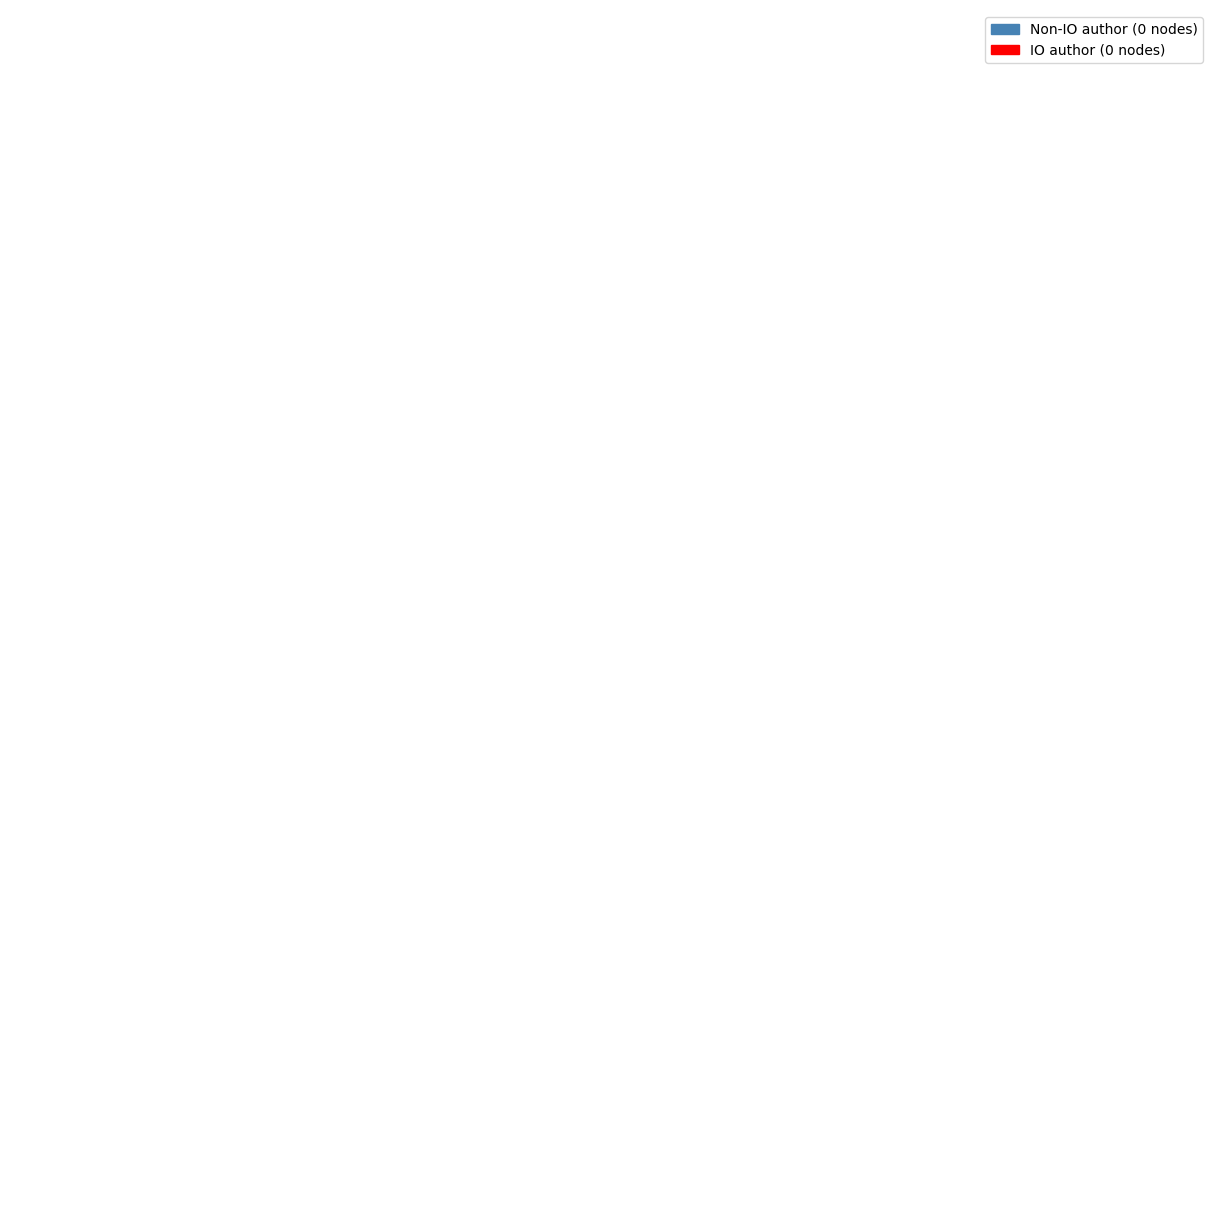

In [ ]:
# Layout Options: 'spring', 'circular', 'random', 'shell', 'spectral', 'kamada_kawai'
plot_accounts_graph(G = G_accounts, folder_output_path = folder_output_path, layout="spring")

# Centralities

## Compute centralities

In [29]:
def compute_all_centralities(G: nx.Graph) -> pd.DataFrame:
    """Compute multiple graph centralities.

    Returns a DataFrame indexed by author/node with:
      - degree
      - betweenness
      - closeness
      - eigenvector
      - pagerank
      - kcore (core number)

    Args:
        G: NetworkX graph

    Returns:
        centralities_df: Centrality measures per node.
    """
    # Degree centrality
    degree = nx.degree_centrality(G)
    print("Calculating: degree_centrality")

    # Betweenness centrality
    betweenness = nx.betweenness_centrality(G, normalized=True)
    print("Calculating: betweenness_centrality")

    # Closeness centrality
    closeness = nx.closeness_centrality(G)
    print("Calculating: closeness_centrality")

    # Eigenvector centrality
    eigen = nx.eigenvector_centrality(G, max_iter=2000)
    print("Calculating: eigenvector_centrality")

    # PageRank
    pagerank = nx.pagerank(G)
    print("Calculating: pagerank")

    # K-core number
    kcore = nx.core_number(G)
    print("Calculating: core_number")

    # Build DataFrame
    node_centralities_df = pd.DataFrame({
        "degree_centrality": degree,
        "betweenness_centrality": betweenness,
        "closeness_centrality": closeness,
        "eigenvector_centrality": eigen,
        "pagerank": pagerank,
        "kcore": kcore,
    })

    return node_centralities_df

In [30]:
node_centralities_df = compute_all_centralities(G_accounts)
node_centralities_df.head()

Calculating: degree_centrality
Calculating: betweenness_centrality
Calculating: closeness_centrality


NetworkXPointlessConcept: cannot compute centrality for the null graph

In [ ]:
def plot_centrality_distributions_all(
    centralities_df,
    output_path: str | Path | None = None,
    bins: int = 30,
):
    """Plot distributions of centrality features for all authors.

    Args:
        centralities_df: DataFrame (index=author, columns=centralities).
        output_path: If given, save figure to this folder path.
        bins: Number of histogram bins.
    """
    features = centralities_df.columns
    n = len(features)

    rows = 2
    cols = math.ceil(n / rows)

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten()  # key fix

    for ax, feature in zip(axes, features):
        ax.hist(centralities_df[feature], bins=bins, alpha=0.8)
        ax.set_title(feature)
        ax.set_xlabel("Value")
        ax.set_ylabel("Counts")


    # remove unused axes (when n is odd)
    for ax in axes[n:]:
        ax.remove()

    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        distributions_output_path = output_path / "centralities_distributions.png"
        fig.savefig(distributions_output_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close(fig)

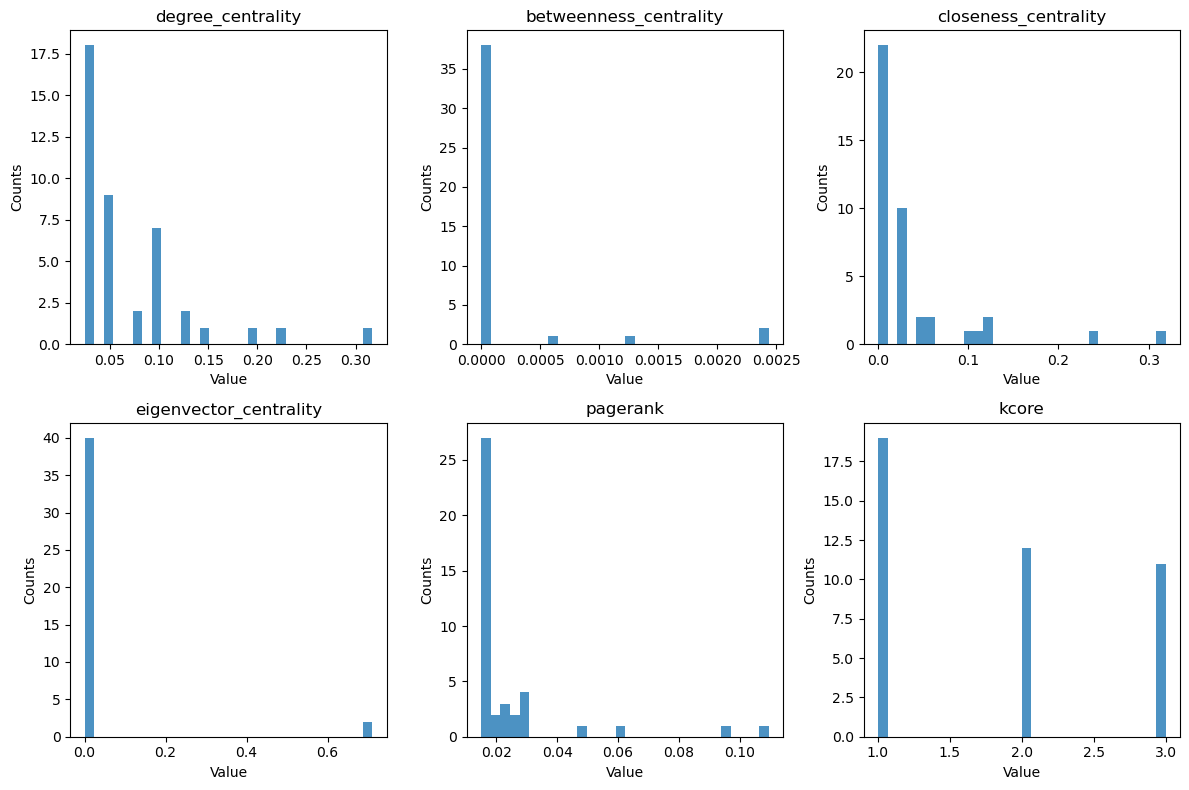

In [ ]:
plot_centrality_distributions_all(node_centralities_df, folder_output_path)

## Information Gain

In [ ]:
def compute_centrality_information_gain(
    node_centralities_df: pd.DataFrame,
    io_authors: set,
) -> pd.Series:
    """Compute information gain (mutual information) between centrality features
    and an IO-author label.

    Args:
        node_centralities_df: DataFrame with authors as index and
            centrality metrics as columns.
        io_authors: Set of author IDs labeled as IO (1). Others are control (0).

    Returns:
        pd.Series: Information gain per centrality feature, sorted descending.
    """
    # Ensure consistent typing
    io_authors = set(map(str, io_authors))
    authors = node_centralities_df.index.astype(str)

    # Build binary label per author
    author_io_tag = authors.isin(io_authors).astype(int)

    # Prepare arrays for sklearn
    X = node_centralities_df.to_numpy()
    y = author_io_tag

    # Compute information gain (MI)
    mi = mutual_info_classif(X, y, discrete_features=False, random_state=42)

    # Convert to Series and sort
    mi_series = pd.Series(
        mi,
        index=node_centralities_df.columns,
        name="information_gain"
    ).sort_values(ascending=False)

    return mi_series

In [ ]:
mi_series = compute_centrality_information_gain(node_centralities_df, io_authors_set)

In [ ]:
def plot_centrality_information_gain(
    mi_series: pd.Series,
    output_path: Path | str | None = None,
    filename: str = "centrality_information_gain.png",
) -> None:
    """Plot and save information gain per centrality feature.

    Args:
        mi_series: Information gain per centrality feature.
        output_path: Directory where the image will be saved.
        filename: Name of the output image file.
    """

    # Create the plot
    plt.figure(figsize=(8, 4))
    mi_series.plot(kind="bar")

    plt.ylabel("Information gain (mutual information)")
    plt.xlabel("Centrality feature")
    plt.title("Information gain of centralities for IO_driver")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    # Save figure
    if output_path is not None:
      output_path = Path(output_path)
      file_path = output_path / filename
      plt.savefig(file_path, dpi=300)
      print(f"Saved fig to: {file_path}")

    # Show figure
    plt.show()

    # Close figure
    plt.close()

Saved fig to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_1/2025_12_16/centrality_information_gain.png


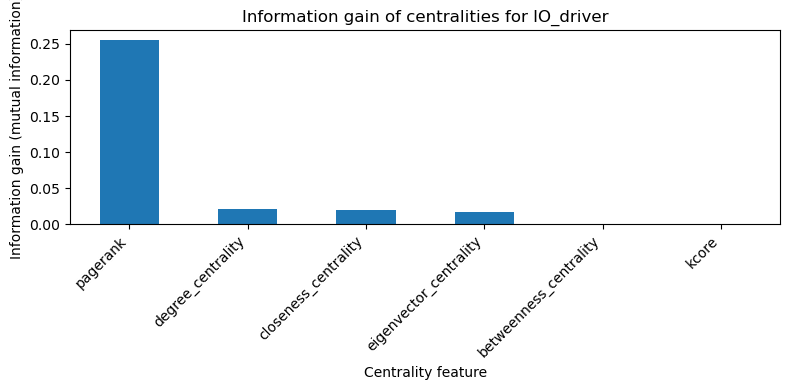

In [ ]:
plot_centrality_information_gain(mi_series, folder_output_path)